# Grid Layout

When assembling test chips or comparison arrays, you often need to arrange
a collection of cells into a regular grid with consistent spacing.
kfactory's grid functions handle this in one call.

| Function | Units | Cell slot size |
|---|---|---|
| `kf.grid` | µm (float) | Uniform — largest bbox in the whole grid |
| `kf.flexgrid` | µm (float) | Flexible — per-column width, per-row height |
| `kf.grid_dbu` | DBU (int) | Uniform — largest bbox in the whole grid |
| `kf.flexgrid_dbu` | DBU (int) | Flexible — per-column width, per-row height |

**`grid` vs `flexgrid`**: `grid` gives every slot the same fixed size (set by
the largest component), so columns and rows stay perfectly aligned like a
spreadsheet. `flexgrid` shrinks each column/row to its actual maximum, saving
area when components vary significantly in size.

All four functions return an `InstanceGroup` so you can apply a common
transformation to the whole block afterwards.

## Setup

In [1]:
import kfactory as kf


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)


L = LAYER()
kf.kcl.infos = L

## 1 · Creating Sample Components

We create a set of `DKCell` components (µm-based) with different sizes.
The size variation is intentional — it makes the difference between `grid`
and `flexgrid` visible.

In [2]:
# (width_µm, height_µm) pairs
sizes_um = [(5, 10), (10, 5), (8, 8), (6, 4), (3, 7), (12, 3)]

components: list[kf.DKCell] = []
for w, h in sizes_um:
    c = kf.DKCell(name=f"box_{w}x{h}")
    c.shapes(c.kcl.layer(L.WG)).insert(kf.kdb.DBox(w, h))
    components.append(c)

print(f"Created {len(components)} components")

Created 6 components


## 2 · `grid` — 1D (Single Row)

Pass a flat list of `DKCell` objects and a spacing in µm.
All cells are arranged in a single row by default.

Every slot is sized to fit the **largest** component's bounding box, so all
cells are equally spaced even when they have different sizes.

Row bbox: 78.5 µm × 10.0 µm
Placed 6 instances


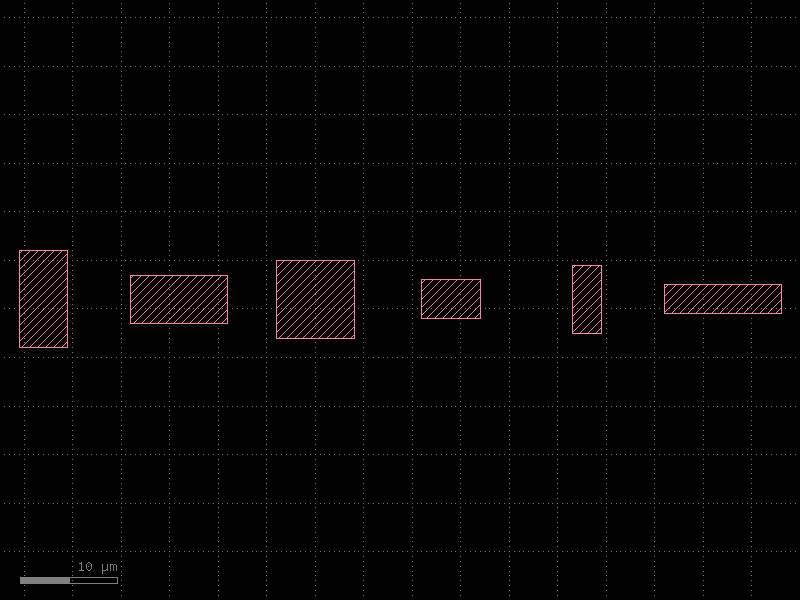

In [3]:
target_row = kf.KCell(name="grid_row")
ig_row = kf.grid(target_row, components, spacing=2.0)

print(
    f"Row bbox: {target_row.dbbox().width():.1f} µm × {target_row.dbbox().height():.1f} µm"
)
print(f"Placed {len(ig_row.insts)} instances")
target_row

## 3 · `grid` — 2D with `shape=`

Pass `shape=(rows, cols)` to reflow a flat list into a 2-D grid.
The slot size is still uniform (largest component sets the pitch in each axis).

2D bbox: 37.0 µm × 20.5 µm


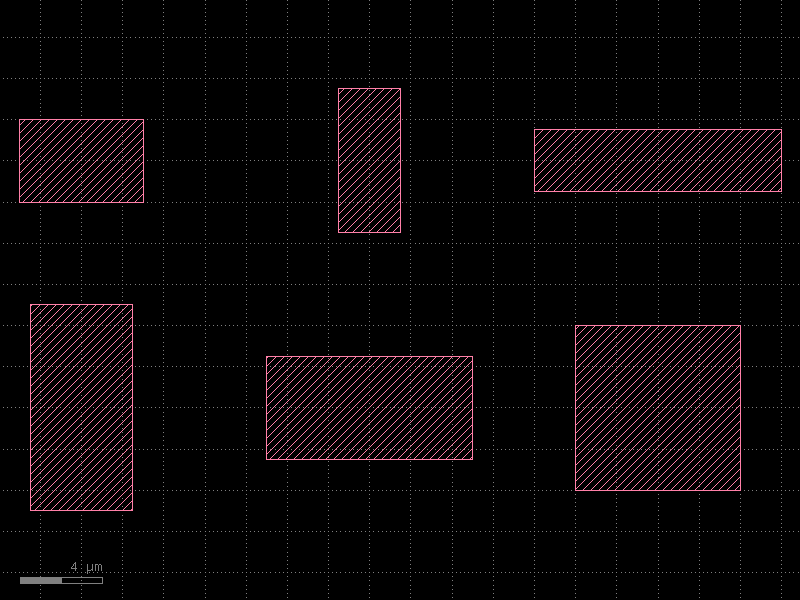

In [4]:
target_2d = kf.KCell(name="grid_2d")
ig_2d = kf.grid(target_2d, components, spacing=2.0, shape=(2, 3))

print(
    f"2D bbox: {target_2d.dbbox().width():.1f} µm × {target_2d.dbbox().height():.1f} µm"
)
target_2d

## 4 · `grid` — Explicit 2D Input

You can supply a list-of-lists directly to control exactly which cell goes in
each position.  This is useful when you want a hand-curated layout rather than
a simple reflow.

Explicit 2D bbox: 37.0 µm × 20.5 µm


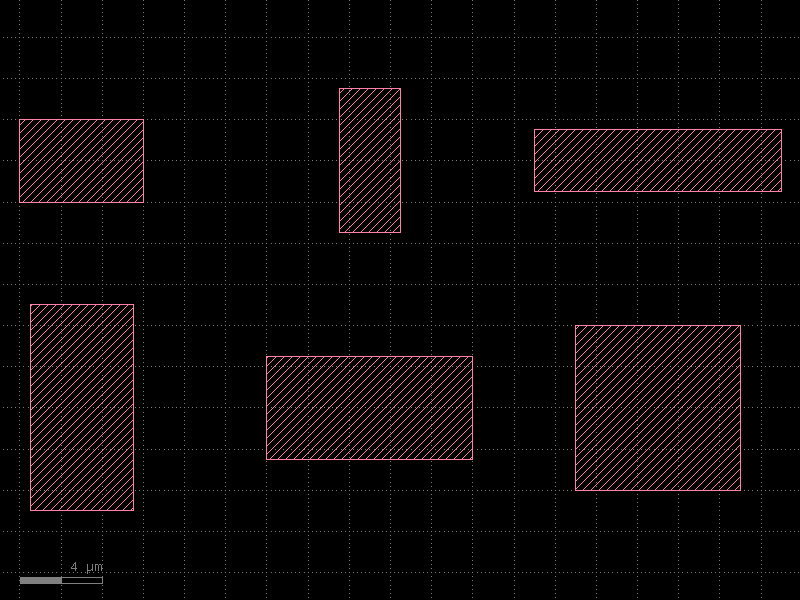

In [5]:
row0 = [components[0], components[1], components[2]]
row1 = [components[3], components[4], components[5]]

target_2d_explicit = kf.KCell(name="grid_2d_explicit")
ig_2d_explicit = kf.grid(target_2d_explicit, [row0, row1], spacing=2.0)

print(
    f"Explicit 2D bbox: {target_2d_explicit.dbbox().width():.1f} µm × {target_2d_explicit.dbbox().height():.1f} µm"
)
target_2d_explicit

## 5 · `flexgrid` — Compact Layout

`flexgrid` gives each **column** its own width (tallest/widest in that column)
and each **row** its own height, so overall footprint is smaller when
components vary in size.

Here the same six components are arranged with `shape=(2, 3)` using both
functions so you can compare the bounding boxes.

grid   bbox: 37.0 × 20.5 µm  (758 µm²)
flexgrid bbox: 32.0 × 19.0 µm  (608 µm²)
Area saving: 20%


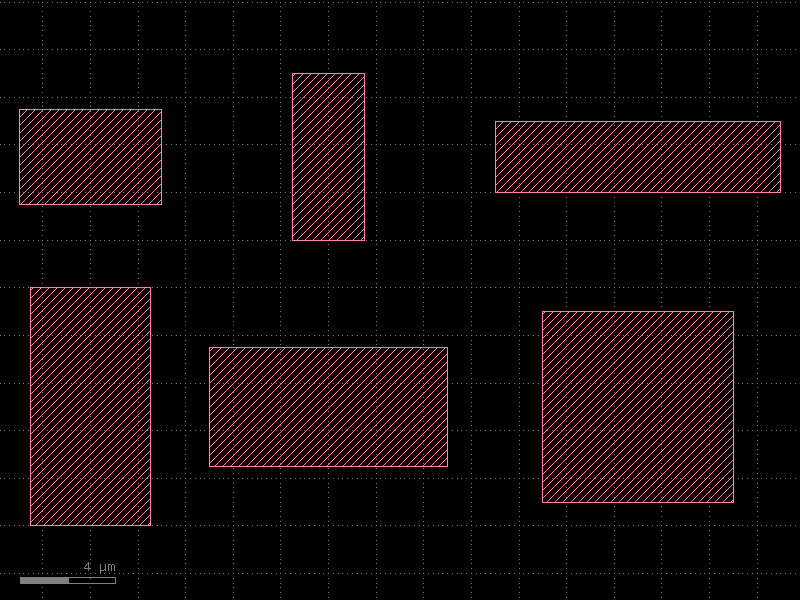

In [6]:
target_flex = kf.KCell(name="flexgrid_2d")
ig_flex = kf.flexgrid(target_flex, components, spacing=2.0, shape=(2, 3))

grid_area = target_2d.dbbox().width() * target_2d.dbbox().height()
flex_area = target_flex.dbbox().width() * target_flex.dbbox().height()

print(f"grid   bbox: {target_2d.dbbox().width():.1f} × {target_2d.dbbox().height():.1f} µm  ({grid_area:.0f} µm²)")
print(f"flexgrid bbox: {target_flex.dbbox().width():.1f} × {target_flex.dbbox().height():.1f} µm  ({flex_area:.0f} µm²)")
print(f"Area saving: {100*(1 - flex_area/grid_area):.0f}%")
target_flex

## 6 · Alignment Options

Both `grid` and `flexgrid` accept `align_x` and `align_y` to control how
components are positioned within their slot:

| Value | Meaning |
|---|---|
| `"center"` (default) | Component centred in its slot |
| `"xmin"` / `"ymin"` | Left-aligned / bottom-aligned |
| `"xmax"` / `"ymax"` | Right-aligned / top-aligned |
| `"origin"` | Component placed so its origin is at the slot position |

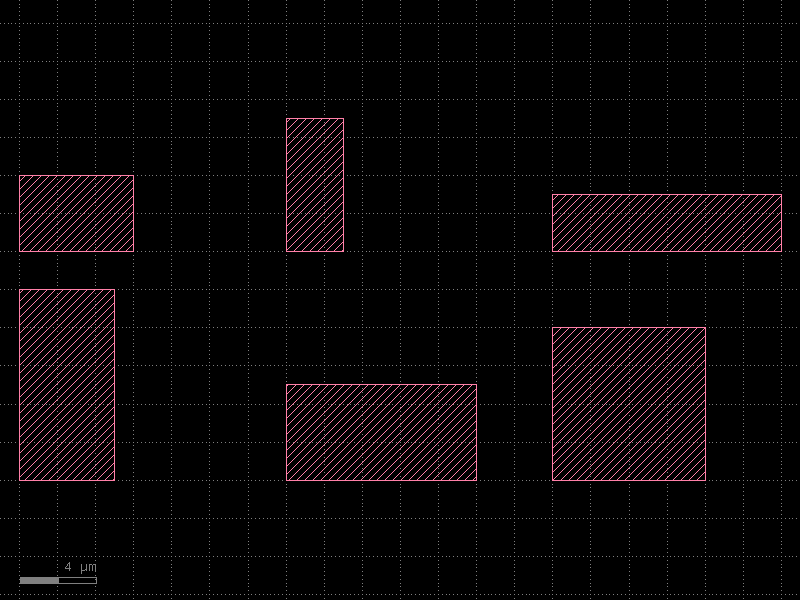

In [7]:
target_aligned = kf.KCell(name="grid_aligned")
ig_aligned = kf.grid(
    target_aligned,
    components,
    spacing=2.0,
    shape=(2, 3),
    align_x="xmin",
    align_y="ymin",
)
target_aligned

## 7 · `grid_dbu` — DBU Variant

If you work with `KCell` (integer DBU coordinates) instead of `DKCell`,
use `grid_dbu` and pass the spacing in DBU.  The API is otherwise identical.

grid_dbu bbox: 78.5 µm × 10.0 µm


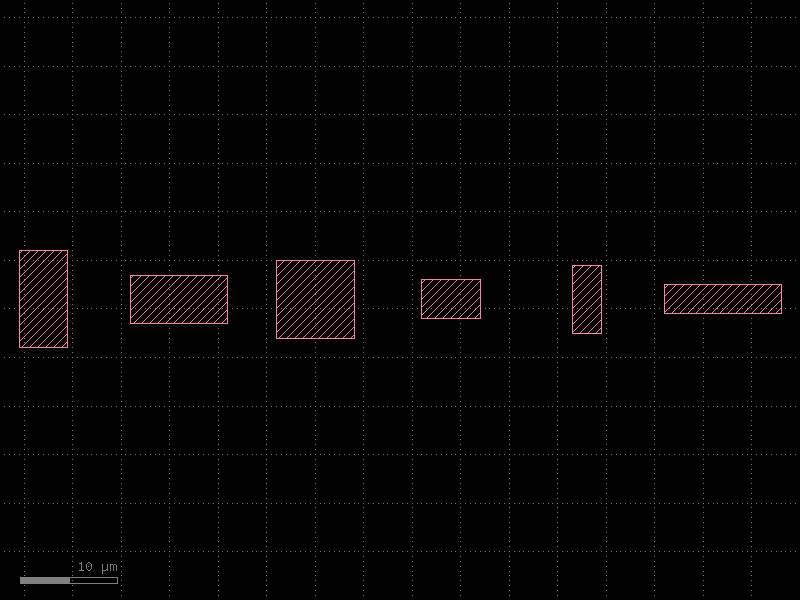

In [8]:
# Build KCell (DBU) components
comps_dbu: list[kf.KCell] = []
for w_um, h_um in sizes_um:
    c = kf.KCell(name=f"kdbox_{w_um}x{h_um}")
    c.shapes(c.kcl.layer(L.WG)).insert(
        kf.kdb.Box(kf.kcl.to_dbu(w_um), kf.kcl.to_dbu(h_um))
    )
    comps_dbu.append(c)

target_dbu = kf.KCell(name="grid_dbu_example")
ig_dbu = kf.grid_dbu(target_dbu, comps_dbu, spacing=kf.kcl.to_dbu(2))

print(
    f"grid_dbu bbox: {target_dbu.dbbox().width():.1f} µm × {target_dbu.dbbox().height():.1f} µm"
)
target_dbu

## 8 · Placing the Grid in a Larger Layout

The returned `InstanceGroup` can be used to move the whole block at once.
Here we pack two sub-grids and place them side-by-side in a top-level cell.

Top bbox: 78.0 µm × 10.0 µm

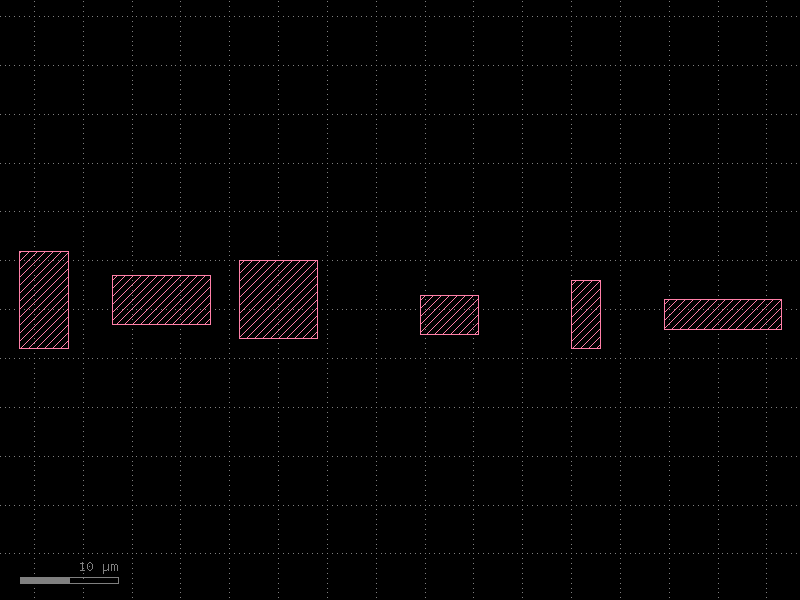

In [9]:
top = kf.KCell(name="top_assembly")

# First sub-grid: first 3 components
sub_a = kf.KCell(name="sub_a")
kf.grid(sub_a, components[:3], spacing=2.0)
inst_a = top << sub_a

# Second sub-grid: last 3 components, placed to the right with a 10 µm gap
sub_b = kf.KCell(name="sub_b")
kf.grid(sub_b, components[3:], spacing=2.0)
inst_b = top << sub_b
gap_dbu = kf.kcl.to_dbu(10)
inst_b.transform(
    kf.kdb.Trans(sub_a.bbox().width() + gap_dbu, 0)
)

print(
    f"Top bbox: {top.dbbox().width():.1f} µm × {top.dbbox().height():.1f} µm"
)
top

## Quick Reference

```python
import kfactory as kf

# µm-based uniform grid (DKCell components)
ig = kf.grid(target, cells, spacing=2.0)
ig = kf.grid(target, cells, spacing=2.0, shape=(rows, cols))
ig = kf.grid(target, [row0, row1], spacing=2.0)        # explicit 2D

# µm-based flexible grid (per-column/row sizing)
ig = kf.flexgrid(target, cells, spacing=2.0, shape=(rows, cols))

# DBU-based variants (KCell components, spacing in dbu)
ig = kf.grid_dbu(target, cells, spacing=kf.kcl.to_dbu(2))
ig = kf.flexgrid_dbu(target, cells, spacing=kf.kcl.to_dbu(2))

# Alignment within each slot
ig = kf.grid(target, cells, spacing=2.0, align_x="xmin", align_y="ymin")

# Move the whole block after placement
inst = top << target
inst.transform(kf.kdb.DCplxTrans(1, 0, False, x_um, y_um))
```

## See Also

| Topic | Where |
|-------|-------|
| Component packing (free placement) | [Utilities: Packing](packing.py) |
| Components overview & gallery | [Components: Overview](../components/cells/overview.py) |
| Creating a full PDK | [PDK: Creating a PDK](../pdk/creating_pdk.py) |
| Instance placement | [Core Concepts: Instances](../concepts/instances.py) |